# Лабораторная работа №5, Вариант 11

## Кластеризация питательных веществ в мясе, рыбе и птице

## Цели и задачи работы
### Цель лабораторной работы: 
научиться производить кластерный анализ данных с
использованием метода К-средних.

**Основные задачи**:

- изучение инструментария Python для реализации алгоритмов кластерного
анализа;
- изучение принципов определения оптимального количества кластеров в
методах кластерного анализа;
- освоение метода К-средних;
- изучение методов визуализации модели и оценки ее корректности.

Датасет - nutrients.csv

Набор данных содержит информацию о содержании питательных веществ в порциях различных продуктов весом 3 унции. Необходимо произвести кластерный анализ для выявления групп продуктов со схожими питательными характеристиками.

### Атрибуты:
- **Name** – название продукта
- **Energy** – количество калорий
- **Protein** – количество белка в граммах
- **Fat** – количество жира в граммах  
- **Calcium** – количество кальция в миллиграммах
- **Iron** – количество железа в миллиграммах

# Импортируем библиотеки и загружаем данные

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv('nutrients.csv')
df.head()

,Name,Energy,Protein,Fat,Calcium,Iron
0,Braised beef,340,20,28,9,2.6
1,Hamburger,245,21,17,9,2.7
2,Roast beef,420,15,39,7,2.0
3,Beefsteak,375,19,32,9,2.6
4,Canned beef,180,22,10,17,3.7


### Получим информацию о датасете

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     27 non-null     object 
 1   Energy   27 non-null     int64  
 2   Protein  27 non-null     int64  
 3   Fat      27 non-null     int64  
 4   Calcium  27 non-null     int64  
 5   Iron     27 non-null     float64
dtypes: float64(1), int64(4), object(1)
memory usage: 1.4+ KB


In [9]:
print(f"Размер датасета: {df.shape}")

Размер датасета: (27, 6)


In [10]:
df.describe()

,Energy,Protein,Fat,Calcium,Iron
count,27.000000,27.000000,27.000000,27.000000,27.000000
mean,207.407407,19.000000,13.481481,43.962963,2.381481
std,101.207806,4.251696,11.257033,78.034254,1.461305
min,45.000000,7.000000,1.000000,5.000000,0.500000
25%,135.000000,16.500000,5.000000,9.000000,1.350000
50%,180.000000,19.000000,9.000000,9.000000,2.500000
75%,282.500000,22.000000,22.500000,31.500000,2.600000
max,420.000000,26.000000,39.000000,367.000000,6.000000


Набор данных состоит из 25 образцов различных продуктов. Каждый продукт описан пятью числовыми атрибутами, характеризующими его питательную ценность. Мы будем решать задачу кластеризации - разбить продукты на группы со схожими питательными характеристиками.

### Проверяем данные на наличие пропущенных значений и выбросов

In [11]:
print(df.isnull().sum())

Name       0
Energy     0
Protein    0
Fat        0
Calcium    0
Iron       0
dtype: int64


### Исключаем невлияющие категориальные признаки

In [12]:
y = df['Name']
df.drop('Name', axis=1, inplace=True)
df.head()

,Energy,Protein,Fat,Calcium,Iron
0,340,20,28,9,2.6
1,245,21,17,9,2.7
2,420,15,39,7,2.0
3,375,19,32,9,2.6
4,180,22,10,17,3.7


### Нормализуем данные

In [13]:
scaler = StandardScaler()
scaler

StandardScaler()

In [14]:
X = scaler.fit_transform(df)

print("Первые 4 нормализованных образцов:")
print(X[:4,:])

Первые 4 нормализованных образцов:
[[ 1.33505901  0.23968064  1.31429714 -0.45658134  0.1523851 ]
 [ 0.37851533  0.47936128  0.31851589 -0.45658134  0.22212065]
 [ 2.14056947 -0.95872255  2.31007839 -0.48269934 -0.26602823]
 [ 1.68746984  0.          1.67639941 -0.45658134  0.1523851 ]]


### Определяем оптимальное количество кластеров с помощью метода локтя

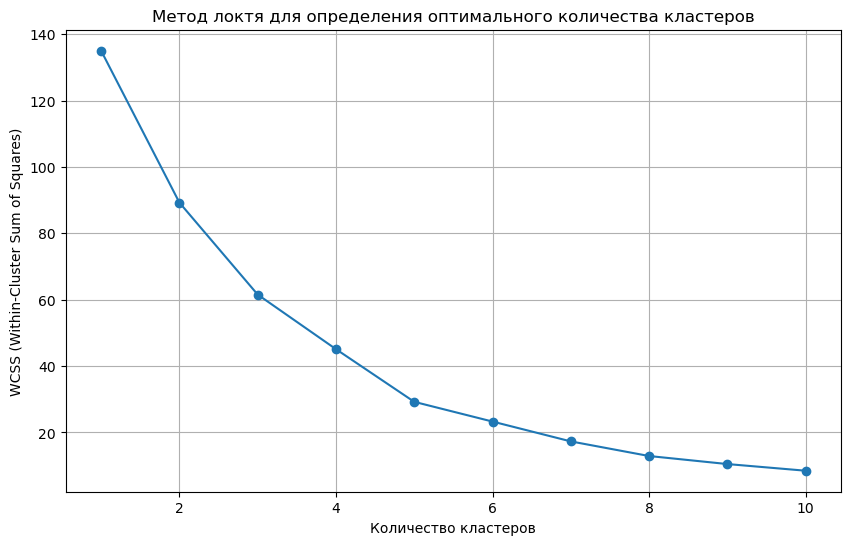

In [15]:
import os
import warnings
# Отключаем предупреждения
warnings.filterwarnings('ignore')

# Устанавливаем несколько переменных окружения
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

На графике метода локтя видно, что оптимальное количество кластеров - 3 или 4. Выберем 3 кластера для дальнейшего анализа.
### Обучаем модель кластеризации

In [16]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

### Предсказываем кластеры и анализируем результат

In [17]:
clusters = kmeans.predict(X)
df['cluster'] = clusters
df.head(18)

,Energy,Protein,Fat,Calcium,Iron,cluster
0,340,20,28,9,2.6,0
1,245,21,17,9,2.7,0
2,420,15,39,7,2.0,0
3,375,19,32,9,2.6,0
4,180,22,10,17,3.7,1
5,115,20,3,8,1.4,1
6,170,25,7,12,1.5,1
7,160,26,5,14,5.9,1
8,265,20,20,9,2.6,0
9,300,18,25,9,2.3,0


### Визуализация результатов с помощью PCA

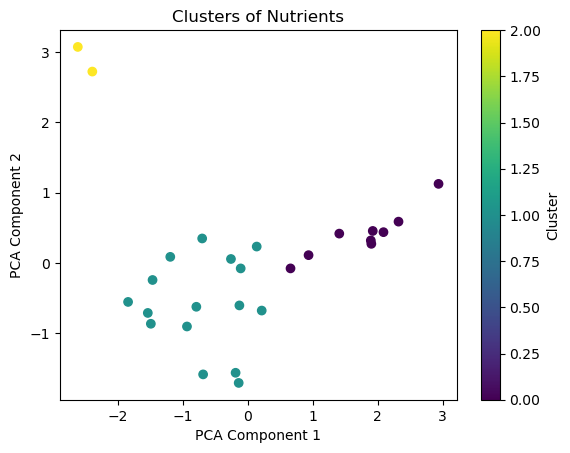

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters of Nutrients')
plt.colorbar(label='Cluster')
plt.show()

### Группируем по кластерам и анализируем средние значения в каждом кластере

In [19]:
# Группируем по кластерам
cluster_groups = df.groupby('cluster')
# Анализ средних значений в каждом кластере
cluster_groups.mean()

,Energy,Protein,Fat,Calcium,Iron
cluster,,,,,
0,331.111111,19.00,27.555556,8.777778,2.466667
1,156.562500,20.25,7.125000,59.500000,1.918750
2,57.500000,9.00,1.000000,78.000000,5.700000


In [20]:
# Добавляем названия нутриентов в исходные данные
df['Name'] = y  
df.head()

,Energy,Protein,Fat,Calcium,Iron,cluster,Name
0,340,20,28,9,2.6,0,Braised beef
1,245,21,17,9,2.7,0,Hamburger
2,420,15,39,7,2.0,0,Roast beef
3,375,19,32,9,2.6,0,Beefsteak
4,180,22,10,17,3.7,1,Canned beef


### Дополнительная визуализация по парам признаков

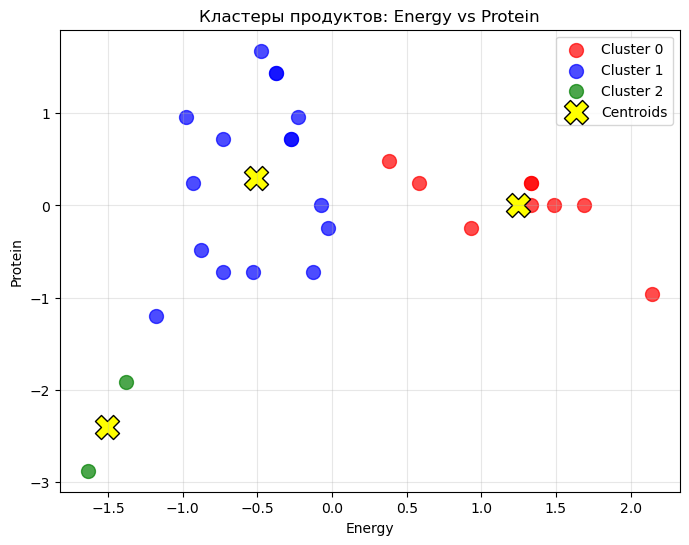

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(X[clusters == 0, 0], X[clusters == 0, 1], s=100, c='red', label='Cluster 0', alpha=0.7)
plt.scatter(X[clusters == 1, 0], X[clusters == 1, 1], s=100, c='blue', label='Cluster 1', alpha=0.7)
plt.scatter(X[clusters == 2, 0], X[clusters == 2, 1], s=100, c='green', label='Cluster 2', alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')

plt.title('Кластеры продуктов: Energy vs Protein')
plt.xlabel('Energy')
plt.ylabel('Protein')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

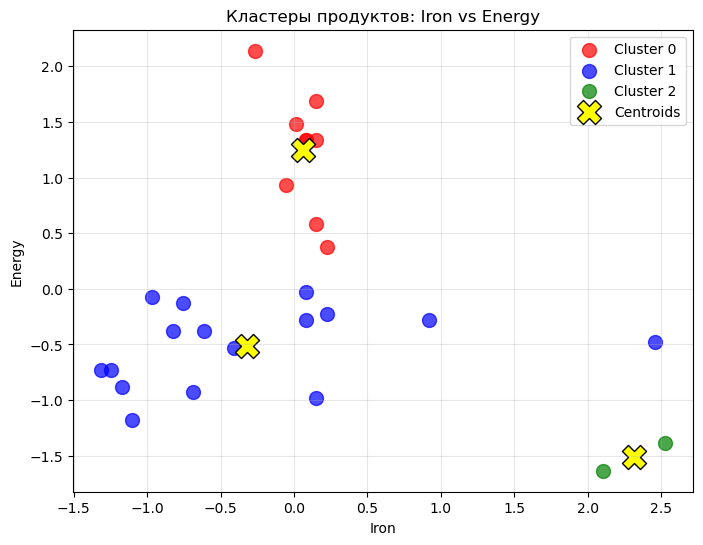

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(X[clusters == 0, 4], X[clusters == 0, 0], s=100, c='red', label='Cluster 0', alpha=0.7)
plt.scatter(X[clusters == 1, 4], X[clusters == 1, 0], s=100, c='blue', label='Cluster 1', alpha=0.7)
plt.scatter(X[clusters == 2, 4], X[clusters == 2, 0], s=100, c='green', label='Cluster 2', alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 4], kmeans.cluster_centers_[:, 0],
            s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')

plt.title('Кластеры продуктов: Iron vs Energy')
plt.xlabel('Iron')
plt.ylabel('Energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

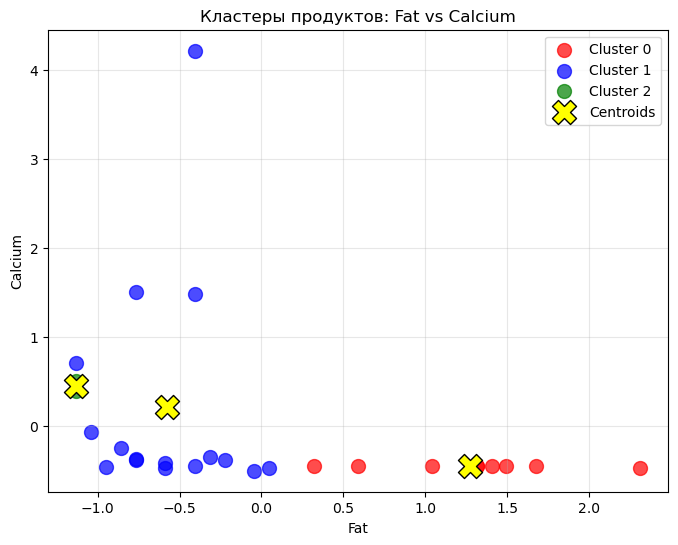

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(X[clusters == 0, 2], X[clusters == 0, 3], s=100, c='red', label='Cluster 0', alpha=0.7)
plt.scatter(X[clusters == 1, 2], X[clusters == 1, 3], s=100, c='blue', label='Cluster 1', alpha=0.7)
plt.scatter(X[clusters == 2, 2], X[clusters == 2, 3], s=100, c='green', label='Cluster 2', alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
            s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')

plt.title('Кластеры продуктов: Fat vs Calcium')
plt.xlabel('Fat')
plt.ylabel('Calcium')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

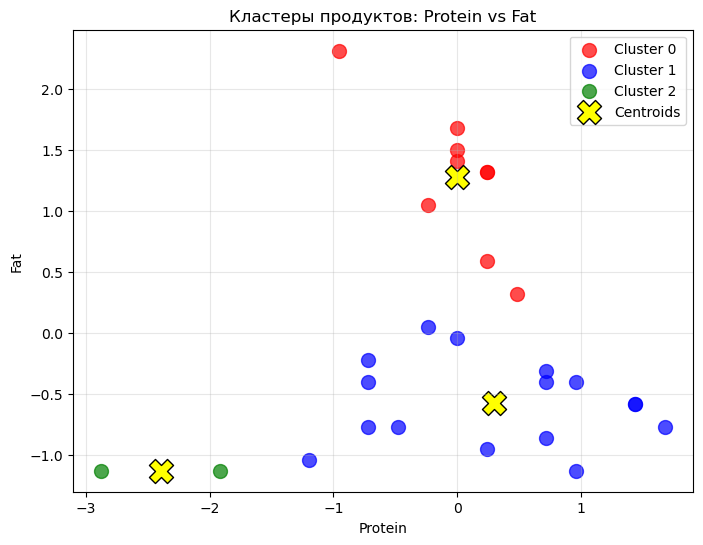

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(X[clusters == 0, 1], X[clusters == 0, 2], s=100, c='red', label='Cluster 0', alpha=0.7)
plt.scatter(X[clusters == 1, 1], X[clusters == 1, 2], s=100, c='blue', label='Cluster 1', alpha=0.7)
plt.scatter(X[clusters == 2, 1], X[clusters == 2, 2], s=100, c='green', label='Cluster 2', alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2],
            s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')

plt.title('Кластеры продуктов: Protein vs Fat')
plt.xlabel('Protein')
plt.ylabel('Fat')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Интерпретация результатов
На основе анализа кластеров можно сделать следующие выводы:
- Кластер 0 (Высокое содержание жиров и калорий)
- Кластер 1 (Средние показатели по калорийности и содержанию жиров)
- Кластер 2 (Низкая калорийность и содержание жиров)

In [21]:
# Выбор нутриентов в каждом кластере
for cluster_num in range(3):
    print(f"\nCluster {cluster_num} nutrients:")
    print(df[df['cluster'] == cluster_num]['Name'].values)


Cluster 0 nutrients:
['Braised beef' 'Hamburger' 'Roast beef' 'Beefsteak' 'Roast lamb leg'
 'Roast lamb shoulder' 'Smoked ham' 'Pork roast' 'Pork simmered']

Cluster 1 nutrients:
['Canned beef' 'Broiled chicken' 'Canned chicken' 'Beef heart'
 'Beef tongue' 'Veal cutlet' 'Baked bluefish' 'Canned crabmeat'
 'Fried haddock' 'Broiled mackerel' 'Canned mackerel' 'Fried perch'
 'Canned salmon' 'Canned sardines' 'Canned tuna' 'Canned shrimp']

Cluster 2 nutrients:
['Raw clams' 'Canned clams']
